# Explore Frame 250 — r2_s04, north LiDAR

Sanity-check the data pipeline against the worked example in `claude.md`: load one OpenLABEL frame, inspect the node table, build the BEV proximity graph, and confirm the H1 hyperedge structure (connected components).

**Expected:** 11 objects, 18 edges at d &le; 10 m, and two multi-node clusters (7 nodes + 2 nodes) plus two isolated nodes (1 and 6) — four connected components in total.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))  # so `import data...` resolves from hgraph/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data.dataset import load_frame, load_sequence, derive_kinematics, speed_label
from data.graph_builder import (
    build_node_features, bev_xy, bev_edges, build_h1_hyperedges,
    yaw_from_quaternion, FEATURE_NAMES,
)


In [2]:
R2_ROOT = "../../r2"
SENSOR_DIR = f"{R2_ROOT}/r2_s04/a9_dataset_r02_s04/labels_point_clouds/s110_lidar_ouster_north"
FRAME_PATH = f"{SENSOR_DIR}/1653330084_184626139_s110_lidar_ouster_north.json"

frame = load_frame(FRAME_PATH)
print(f"frame_id={frame.frame_id}  timestamp={frame.timestamp:.6f}  "
      f"weather={frame.weather}  time_of_day={frame.time_of_day}")
print(f"n_objects={len(frame.objects)}")


frame_id=250  timestamp=1653330084.184626  weather=RAINY  time_of_day=NIGHT
n_objects=11


## Node table

Velocity is derived from the previous frame of the same sensor sequence (per-UUID displacement), so we load the full north sequence and pull kinematics for frame 250's index. Objects with `num_points <= 2` (nodes 4 and 10) have position inferred rather than measured, so velocity derivation is skipped for them — exactly the two stress-test cases called out in claude.md.

In [3]:
sequence = load_sequence(SENSOR_DIR)
frame_idx = next(i for i, fr in enumerate(sequence) if fr.frame_id == frame.frame_id
                  and fr.timestamp == frame.timestamp)
kinematics = derive_kinematics(sequence)[frame_idx]

rows = []
for i, obj in enumerate(frame.objects):
    x, y, z = obj.xyz
    qx, qy, qz, qw = obj.quat
    yaw = yaw_from_quaternion(qx, qy, qz, qw)
    l, w, h = obj.lwh
    kin = kinematics.get(obj.uuid)
    rows.append({
        "idx": i, "uuid": obj.uuid[:8], "cls": obj.cls,
        "x": round(x, 2), "y": round(y, 2), "z": round(z, 2), "yaw": round(yaw, 2),
        "l": l, "w": w, "h": h,
        "num_points": obj.num_points, "occlusion": obj.occlusion,
        "vx": round(kin.vx, 2) if kin else None,
        "vy": round(kin.vy, 2) if kin else None,
        "speed": round(kin.speed, 2) if kin else None,
        "speed_label": speed_label(kin.speed) if kin else None,
    })

node_table = pd.DataFrame(rows).set_index("idx")
node_table


,uuid,cls,x,y,z,yaw,l,w,h,num_points,occlusion,vx,vy,speed,speed_label
idx,,,,,,,,,,,,,,,
0,d93e6f8a,CAR,44.43,12.12,-7.15,2.94,4.1881,2.0550,1.7000,9,NOT_OCCLUDED,0.00,-0.00,0.00,0.0
1,4afabf3b,CAR,19.06,-3.45,-6.73,1.37,4.6370,1.9474,1.7000,352,NOT_OCCLUDED,0.69,2.88,2.96,1.0
2,befedc57,TRAILER,48.77,14.16,-7.15,2.95,6.7788,2.9345,1.7000,9,NOT_OCCLUDED,0.00,-0.00,0.00,0.0
3,6ea9e8bf,TRUCK,44.28,15.01,-6.67,2.95,2.2023,2.9213,2.6595,9,NOT_OCCLUDED,0.00,-0.00,0.00,0.0
4,e38fb989,CAR,52.41,10.67,-6.84,2.96,4.1260,1.7497,1.3940,1,NOT_OCCLUDED,NaN,NaN,NaN,NaN
5,f830d3f6,BUS,29.28,35.79,-7.10,-2.12,13.0740,3.4932,2.9622,30,NOT_OCCLUDED,-1.18,-2.33,2.61,1.0
6,f0fe652a,CAR,8.80,21.67,-6.66,2.73,4.6970,1.8996,1.6502,356,NOT_OCCLUDED,-6.41,2.98,7.07,2.0
7,6d218d5f,TRUCK,44.58,8.36,-6.58,2.97,2.9231,2.3731,2.5787,15,NOT_OCCLUDED,-0.15,0.02,0.15,0.0
8,f8bfb34d,CAR,22.21,39.11,-8.05,-2.11,4.1311,1.9037,1.5379,13,NOT_OCCLUDED,0.01,0.02,0.02,0.0


## BEV proximity graph and H1 hyperedges

Edges connect any pair of objects with BEV distance &le; 10 m. H1 hyperedges are the connected components of that graph — every node lands in exactly one hyperedge, including isolated nodes as singleton hyperedges.

In [4]:
xy = bev_xy(frame)
edges = bev_edges(xy, radius=10.0)
hyperedge_ids = build_h1_hyperedges(xy, radius=10.0)

print(f"n_edges={len(edges)}")
print(f"n_hyperedges (connected components)={len(set(hyperedge_ids.tolist()))}")
for eid in sorted(set(hyperedge_ids.tolist())):
    members = [i for i, h in enumerate(hyperedge_ids) if h == eid]
    print(f"  hyperedge {eid}: nodes {members}  ({len(members)} objects)")


n_edges=18
n_hyperedges (connected components)=4
  hyperedge 0: nodes [0, 2, 3, 4, 7, 9, 10]  (7 objects)
  hyperedge 1: nodes [1]  (1 objects)
  hyperedge 2: nodes [5, 8]  (2 objects)
  hyperedge 3: nodes [6]  (1 objects)


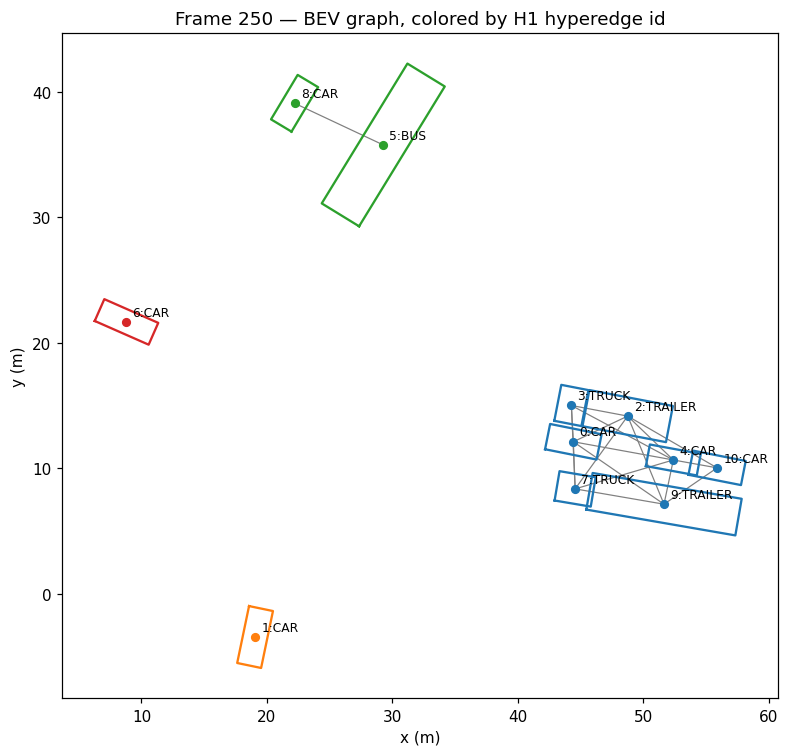

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))

cmap = plt.get_cmap("tab10")
for i, j in edges:
    ax.plot([xy[i, 0], xy[j, 0]], [xy[i, 1], xy[j, 1]], color="gray", linewidth=0.8, zorder=1)

for i, obj in enumerate(frame.objects):
    color = cmap(hyperedge_ids[i] % 10)
    x, y = xy[i]
    l, w, _ = obj.lwh
    yaw = yaw_from_quaternion(*obj.quat)
    corners = np.array([[l / 2, w / 2], [l / 2, -w / 2], [-l / 2, -w / 2], [-l / 2, w / 2], [l / 2, w / 2]])
    R = np.array([[np.cos(yaw), -np.sin(yaw)], [np.sin(yaw), np.cos(yaw)]])
    corners = corners @ R.T + [x, y]
    ax.plot(corners[:, 0], corners[:, 1], color=color, linewidth=1.5, zorder=2)
    ax.scatter([x], [y], color=color, s=25, zorder=3)
    ax.annotate(f"{i}:{obj.cls}", (x, y), textcoords="offset points", xytext=(4, 4), fontsize=8)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Frame 250 — BEV graph, colored by H1 hyperedge id")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


## First sanity check

From claude.md: *"load one frame, confirm 11 nodes, 18 edges, 2 components."* The "2 components" refers to the two multi-node clusters the worked example names (7-node and 2-node); nodes 1 and 6 are isolated singleton hyperedges on top of those, for 4 connected components total in the strict graph-theory sense.

In [6]:
assert len(frame.objects) == 11, len(frame.objects)
assert len(edges) == 18, len(edges)

sizes = sorted(np.bincount(hyperedge_ids).tolist(), reverse=True)
assert sizes == [7, 2, 1, 1], sizes  # two named clusters + two isolated nodes

isolated = [i for i, h in enumerate(hyperedge_ids)
            if np.sum(hyperedge_ids == h) == 1]
assert isolated == [1, 6], isolated

print("PASS: 11 nodes, 18 edges, clusters of size", sizes,
      "-> 2 multi-node components (7 + 2) + isolated nodes", isolated)


PASS: 11 nodes, 18 edges, clusters of size [7, 2, 1, 1] -> 2 multi-node components (7 + 2) + isolated nodes [1, 6]
